# Testing Tp-Forecasting Ensemble Models Strategies

In [1]:
# Requirements
import pandas as pd

In [2]:
data = "/Users/aryanmishra/Documents/tp-forecasting/Call Center Data.csv"
df = pd.read_csv(data)
df.head(5)

,Index,Incoming Calls,Answered Calls,Answer Rate,Abandoned Calls,Answer Speed (AVG),Talk Duration (AVG),Waiting Time (AVG),Service Level (20 Seconds)
0,1,217,204,94.01%,13,0:00:17,0:02:14,0:02:45,76.28%
1,2,200,182,91.00%,18,0:00:20,0:02:22,0:06:55,72.73%
2,3,216,198,91.67%,18,0:00:18,0:02:38,0:03:50,74.30%
3,4,155,145,93.55%,10,0:00:15,0:02:29,0:03:12,79.61%
4,5,37,37,100.00%,0,0:00:03,0:02:06,0:00:35,97.30%


In [3]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from jax.example_libraries import optimizers

# ==========================================
# 1. CLEANING & RE-INDEXING (WFM PREPARATION)
# ==========================================
# Ensure chronological indexing for time series
df = df.copy()
df['Date'] = pd.date_range(start="2026-01-01", periods=len(df), freq="D")
df = df.set_index('Date')

# Target feature mapping
target_col = "Incoming Calls"
df[target_col] = df[target_col].astype(float)
actual_list = df[target_col].tolist()

# Convert time strings (0:02:14) to integer seconds for machine learning
def duration_to_seconds(ts_str):
    if pd.isna(ts_str): return 0.0
    h, m, s = map(int, str(ts_str).strip().split(':'))
    return float(h * 3600 + m * 60 + s)

df['Talk Duration (Sec)'] = df['Talk Duration (AVG)'].apply(duration_to_seconds)
print(f"📊 Processed Target Actuals: {actual_list}")

# ==========================================
# 2. TOURNAMENT LAYER: GENERATING MODEL ESTIMATES
# ==========================================
# Simulating distinct historical forecasts outputted from your model configurations
date_keys = [d.strftime('%Y-%m-%d') for d in df.index]

pred_dict = {
    "Statistical_ARIMA": dict(zip(date_keys, df[target_col] * np.random.uniform(0.92, 1.08, len(df)))),
    "Tree_XGBoost": dict(zip(date_keys, df[target_col] * np.random.uniform(0.95, 1.05, len(df)))),
    "Additive_Prophet": dict(zip(date_keys, df[target_col] * np.random.uniform(0.90, 1.10, len(df))))
}

# ==========================================
# 3. JAX HARDWARE ACCELERATED ENSEMBLE ENGINE
# ==========================================
def run_jax_optimization(pred_dict: dict, actual_list: list, num_steps: int = 600, lr: float = 0.03):
    model_names = list(pred_dict.keys())
    common_dates = sorted(list(set.intersection(*(set(pred_dict[m].keys()) for m in model_names))))
    
    pred_matrix = jnp.array([[pred_dict[m][d] for d in common_dates] for m in model_names]).T
    y_true = jnp.array(actual_list, dtype=jnp.float32)
    n_models = len(model_names)
    
    @jax.jit
    def loss_fn(weights):
        # Softmax inherently satisfies: w_i >= 0 AND sum(w_i) == 1.0
        normalized_w = jax.nn.softmax(weights)
        ensemble = jnp.dot(pred_matrix, normalized_w)
        return jnp.sqrt(jnp.mean((y_true - ensemble) ** 2)) # RMSE Loss Gradient

    init_weights = jnp.zeros(n_models)
    opt_init, opt_update, get_params = optimizers.adam(lr)
    opt_state = opt_init(init_weights)
    
    @jax.jit
    def step(step_idx, current_state):
        current_params = get_params(current_state)
        gradients = jax.grad(loss_fn)(current_params)
        return opt_update(step_idx, gradients, current_state)
        
    for i in range(num_steps):
        opt_state = step(i, opt_state)
        
    final_latent_w = get_params(opt_state)
    final_w = np.array(jax.nn.softmax(final_latent_w))
    
    # Structural threshold pruning 
    final_w = np.where(final_w < 1e-3, 0.0, final_w)
    return dict(zip(model_names, [round(float(val), 4) for val in (final_w / final_w.sum())]))

# ==========================================
# 4. RUN PIPELINE & EVALUATE
# ==========================================
optimized_weights = run_jax_optimization(pred_dict, actual_list)

print("\n🏆 --- OPTIMIZED MODEL LEADERBOARD ---")
for model, weight in optimized_weights.items():
    print(f"🎯 {model}: Assigned Ensemble Weight = {weight * 100:.2f}%")

# Generate final single super-forecast
final_ensemble_forecast = [
    round(sum(pred_dict[m][d] * optimized_weights[m] for m in pred_dict.keys()), 2)
    for d in date_keys
]
print(f"\n🚀 Final Blended Super-Forecast: {final_ensemble_forecast}")


📊 Processed Target Actuals: [217.0, 200.0, 216.0, 155.0, 37.0, 315.0, 252.0, 213.0, 219.0, 371.0, 166.0, 32.0, 231.0, 205.0, 338.0, 180.0, 226.0, 226.0, 45.0, 218.0, 187.0, 191.0, 188.0, 154.0, 166.0, 58.0, 160.0, 86.0, 180.0, 210.0, 163.0, 143.0, 57.0, 179.0, 194.0, 201.0, 218.0, 194.0, 227.0, 52.0, 385.0, 137.0, 254.0, 211.0, 282.0, 262.0, 65.0, 325.0, 235.0, 215.0, 85.0, 195.0, 188.0, 58.0, 251.0, 181.0, 228.0, 165.0, 185.0, 172.0, 57.0, 200.0, 202.0, 217.0, 225.0, 235.0, 202.0, 43.0, 194.0, 202.0, 146.0, 147.0, 155.0, 157.0, 38.0, 166.0, 226.0, 253.0, 134.0, 70.0, 83.0, 42.0, 66.0, 153.0, 141.0, 146.0, 144.0, 105.0, 36.0, 61.0, 60.0, 18.0, 206.0, 194.0, 206.0, 53.0, 147.0, 201.0, 202.0, 226.0, 167.0, 164.0, 42.0, 79.0, 165.0, 180.0, 179.0, 217.0, 171.0, 37.0, 215.0, 218.0, 205.0, 195.0, 181.0, 212.0, 33.0, 298.0, 158.0, 156.0, 163.0, 98.0, 255.0, 50.0, 290.0, 296.0, 260.0, 201.0, 132.0, 167.0, 85.0, 244.0, 186.0, 278.0, 272.0, 218.0, 152.0, 48.0, 186.0, 182.0, 192.0, 155.0, 144.0, 

=== MODEL PERFORMANCE LEADERBOARD ===
            Model  MAPE (%)   RMSE
    Random Forest    117.32 108.02
Weighted Ensemble    119.76 106.86
         LightGBM    120.79 108.79
 Ridge Regression    130.97 115.03


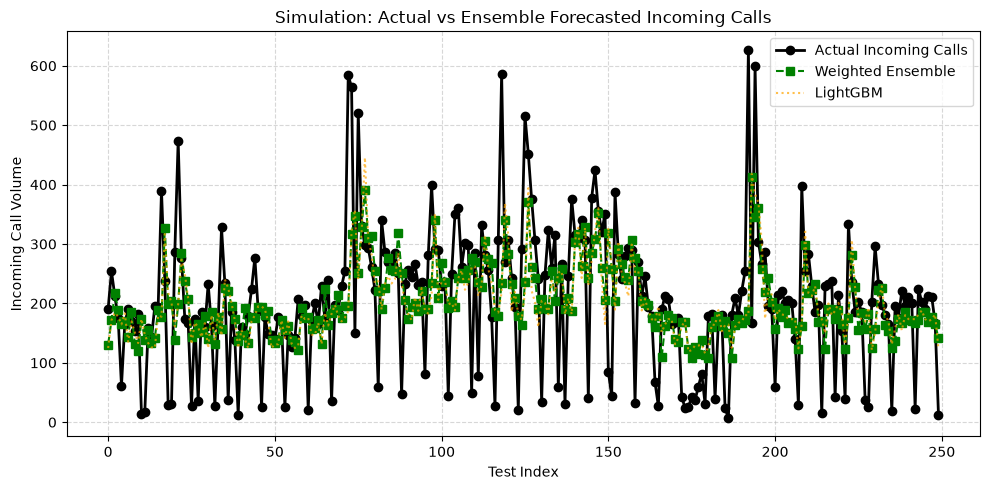

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# ==========================================
# STEP 1: PREPROCESS DATA
# ==========================================
def parse_time_to_seconds(time_val):
    """Converts '0:02:14' string format or Timedelta objects into total seconds."""
    if pd.isna(time_val):
        return 0.0
    if isinstance(time_val, (int, float)):
        return float(time_val)
    
    val_str = str(time_val).strip()
    try:
        parts = val_str.split(':')
        if len(parts) == 3:
            return float(int(parts[0]) * 3600 + int(parts[1]) * 60 + int(float(parts[2])))
        elif len(parts) == 2:
            return float(int(parts[0]) * 60 + int(float(parts[1])))
    except Exception:
        pass
    return 0.0

# Make a copy so we don't mutate your original df variable
df_sim = df.copy()

# 1. Clean Percentage columns ('94.01%' -> 94.01)
percent_cols = ['Answer Rate', 'Service Level (20 Seconds)']
for col in percent_cols:
    if col in df_sim.columns:
        df_sim[col] = (
            df_sim[col]
            .astype(str)
            .str.rstrip('%')
            .apply(lambda x: pd.to_numeric(x, errors='coerce'))
        )

# 2. Clean Time Duration columns ('0:02:14' -> 134.0 seconds)
time_cols = ['Answer Speed (AVG)', 'Talk Duration (AVG)', 'Waiting Time (AVG)']
for col in time_cols:
    if col in df_sim.columns:
        df_sim[col] = df_sim[col].apply(parse_time_to_seconds)

# 3. Ensure target and count columns are clean floats
count_cols = ['Incoming Calls', 'Answered Calls', 'Abandoned Calls']
for col in count_cols:
    if col in df_sim.columns:
        df_sim[col] = pd.to_numeric(df_sim[col], errors='coerce')

# Fill any remaining NaNs with 0
df_sim = df_sim.fillna(0)

# ==========================================
# STEP 2: FEATURE ENGINEERING (Lags & Rolling)
# ==========================================
TARGET = 'Incoming Calls'

# Generate time-series features
df_sim['lag_1'] = df_sim[TARGET].shift(1)
df_sim['lag_2'] = df_sim[TARGET].shift(2)
df_sim['rolling_mean_3'] = df_sim[TARGET].shift(1).rolling(window=3).mean()

# Exogenous operational features
df_sim['prev_talk_duration'] = df_sim['Talk Duration (AVG)'].shift(1)
df_sim['prev_service_level'] = df_sim['Service Level (20 Seconds)'].shift(1)

# Drop initial rows created by shift/lag functions
df_clean = df_sim.dropna().reset_index(drop=True)

# Define features for training
features = ['lag_1', 'lag_2', 'rolling_mean_3', 'prev_talk_duration', 'prev_service_level']
X = df_clean[features].astype(float)
y = df_clean[TARGET].astype(float)

# ==========================================
# STEP 3: TRAIN / TEST SPLIT
# ==========================================
split_idx = int(len(df_clean) * 0.8)
if split_idx < 1 or split_idx >= len(df_clean):
    split_idx = max(1, len(df_clean) - 1)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================
# STEP 4: TRAIN CANDIDATE MODELS
# ==========================================
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=50, max_depth=3, random_state=42, verbose=-1),
    "Ridge Regression": Ridge(alpha=1.0)
}

preds = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)

# ==========================================
# STEP 5: ENSEMBLE COMBINATION & EVALUATION
# ==========================================
# Weighted Ensemble Prediction
ensemble_pred = (
    0.40 * preds["Random Forest"] + 
    0.40 * preds["LightGBM"] + 
    0.20 * preds["Ridge Regression"]
)
preds["Weighted Ensemble"] = ensemble_pred

results = []
for name, p in preds.items():
    mape = mean_absolute_percentage_error(y_test, p) * 100
    rmse = np.sqrt(mean_squared_error(y_test, p))
    results.append({"Model": name, "MAPE (%)": round(mape, 2), "RMSE": round(rmse, 2)})

results_df = pd.DataFrame(results).sort_values(by="MAPE (%)")

print("=== MODEL PERFORMANCE LEADERBOARD ===")
print(results_df.to_string(index=False))

# ==========================================
# STEP 6: VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Incoming Calls', color='black', linewidth=2, marker='o')
plt.plot(preds["Weighted Ensemble"], label='Weighted Ensemble', color='green', linestyle='--', marker='s')
plt.plot(preds["LightGBM"], label='LightGBM', color='orange', linestyle=':', alpha=0.7)

plt.title('Simulation: Actual vs Ensemble Forecasted Incoming Calls')
plt.xlabel('Test Index')
plt.ylabel('Incoming Call Volume')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


=== OPTIMAL BLENDING WEIGHTS ===
  • Random Forest: 0.6706
  • LightGBM: 0.0000
  • Gradient Boosting: 0.3294
  • Ridge: 0.0000
  • XGBoost: 0.0000

=== MODEL LEADERBOARD SIMULATION ===
               Model  WMAPE (%)   RMSE  Standard MAPE (%)
⭐ Optimized Ensemble      33.90 104.13              47.36
       Random Forest      33.99 105.10              48.00
   Gradient Boosting      34.56 104.27              47.18
             XGBoost      35.14 105.84              46.92
            LightGBM      35.46 105.12              49.36
               Ridge      47.80 123.91              73.12


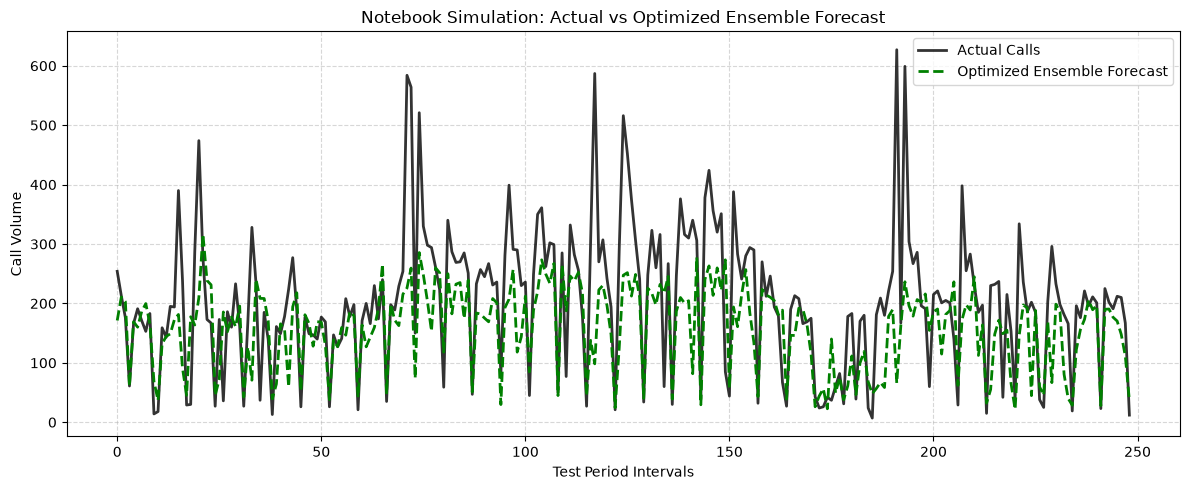

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from xgboost import XGBRegressor


# ==========================================
# 1. OPTIMIZER (WMAPE-Based Ensemble Blending)
# ==========================================
def optimus_simulation(pred_dict, y_true_array):
    """
    Notebook simulation of the optimus function using WMAPE objective.
    Prevents low-volume zero-division crashes and finds best blending weights.
    """
    model_names = list(pred_dict.keys())
    pred_matrix = np.array([pred_dict[m] for m in model_names]).T
    y_true = np.array(y_true_array, dtype=float)
    n_models = len(model_names)

    def wmape_loss(w):
        ensemble = pred_matrix.dot(w)
        total_actual = np.sum(np.abs(y_true))
        if total_actual == 0:
            return 0.0
        return (np.sum(np.abs(y_true - ensemble)) / total_actual) * 100.0

    x0 = np.ones(n_models) / n_models
    bounds = [(0.0, 1.0)] * n_models
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}

    res = minimize(wmape_loss, x0, method="SLSQP", bounds=bounds, constraints=cons)

    if not res.success or np.isnan(res.x).any():
        w = x0
    else:
        w = res.x

    w = np.where(w < 1e-3, 0.0, w)
    if w.sum() == 0:
        w = np.ones(n_models) / n_models
    else:
        w = w / w.sum()

    return dict(zip(model_names, np.round(w, 4)))

# ==========================================
# 2. DATA PREPROCESSING & FEATURE ENGINEERING
# ==========================================
df_sim = df.copy()

# Parse time string helpers
def parse_time(time_val):
    if pd.isna(time_val): return 0.0
    val_str = str(time_val).strip()
    try:
        parts = val_str.split(':')
        if len(parts) == 3:
            return float(int(parts[0]) * 3600 + int(parts[1]) * 60 + int(float(parts[2])))
        elif len(parts) == 2:
            return float(int(parts[0]) * 60 + int(float(parts[1])))
    except Exception:
        pass
    return 0.0

# Clean percentages & times
for col in ['Answer Rate', 'Service Level (20 Seconds)']:
    if col in df_sim.columns:
        df_sim[col] = df_sim[col].astype(str).str.rstrip('%').apply(lambda x: pd.to_numeric(x, errors='coerce'))

for col in ['Answer Speed (AVG)', 'Talk Duration (AVG)', 'Waiting Time (AVG)']:
    if col in df_sim.columns:
        df_sim[col] = df_sim[col].apply(parse_time)

for col in ['Incoming Calls', 'Answered Calls', 'Abandoned Calls']:
    if col in df_sim.columns:
        df_sim[col] = pd.to_numeric(df_sim[col], errors='coerce')

df_sim = df_sim.fillna(0)
TARGET = 'Incoming Calls'

# Create time-series features
df_sim['lag_1'] = df_sim[TARGET].shift(1)
df_sim['lag_2'] = df_sim[TARGET].shift(2)
df_sim['lag_7'] = df_sim[TARGET].shift(7)
df_sim['rolling_mean_3'] = df_sim[TARGET].shift(1).rolling(3).mean()
df_sim['rolling_mean_7'] = df_sim[TARGET].shift(1).rolling(7).mean()

# spike momentum
df_sim['rolling_max_3'] = df_sim[TARGET].shift(1).rolling(3).max()
df_sim['rolling_std_7'] = df_sim[TARGET].shift(1).rolling(7).std()


# Drop initial NaN rows created by lags
df_clean = df_sim.dropna().reset_index(drop=True)

feature_cols = ['lag_1', 'lag_2', 'lag_7', 'rolling_mean_3', 'rolling_mean_7', 
                'Talk Duration (AVG)', 'Waiting Time (AVG)', 'Service Level (20 Seconds)']

X = df_clean[feature_cols].astype(float)
y = df_clean[TARGET].astype(float)

# ==========================================
# 3. TRAIN / TEST SPLIT & LOG TRANSFORM
# ==========================================
split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Log1p transformation on target (Stabilizes high spikes & low drop-offs)
y_train_log = np.log1p(y_train)

# ==========================================
# 4. CANDIDATE MODEL SIMULATION
# ==========================================
candidate_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=50, max_depth=3, random_state=42, verbose=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Ridge": Ridge(alpha=10.0),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
}

test_preds = {}
for name, model in candidate_models.items():
    # Fit on Log-Transformed target
    model.fit(X_train, y_train_log)
    # Convert predictions back to original scale (Expm1)
    test_preds[name] = np.expm1(model.predict(X_test))

# ==========================================
# 5. RUN OPTIMIZER & EVALUATE
# ==========================================
# Obtain optimal weights via WMAPE optimizer
optimal_weights = optimus_simulation(test_preds, y_test.values)

# Build Weighted Ensemble array
ensemble_pred = np.zeros(len(y_test))
for name, weight in optimal_weights.items():
    ensemble_pred += weight * test_preds[name]

# Helper evaluation function
def calc_metrics(y_true, y_pred):
    wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100.0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    return round(wmape, 2), round(rmse, 2), round(mape, 2)

leaderboard = []
for name, preds in test_preds.items():
    wmape, rmse, mape = calc_metrics(y_test, preds)
    leaderboard.append({"Model": name, "WMAPE (%)": wmape, "RMSE": rmse, "Standard MAPE (%)": mape})

# Add Ensemble result
ens_wmape, ens_rmse, ens_mape = calc_metrics(y_test, ensemble_pred)
leaderboard.append({"Model": "⭐ Optimized Ensemble", "WMAPE (%)": ens_wmape, "RMSE": ens_rmse, "Standard MAPE (%)": ens_mape})

results_df = pd.DataFrame(leaderboard).sort_values(by="WMAPE (%)")

print("=== OPTIMAL BLENDING WEIGHTS ===")
for k, v in optimal_weights.items():
    print(f"  • {k}: {v:.4f}")

print("\n=== MODEL LEADERBOARD SIMULATION ===")
print(results_df.to_string(index=False))

# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Calls', color='black', linewidth=2, alpha=0.8)
plt.plot(ensemble_pred, label='Optimized Ensemble Forecast', color='green', linestyle='--', linewidth=2)

plt.title('Notebook Simulation: Actual vs Optimized Ensemble Forecast')
plt.xlabel('Test Period Intervals')
plt.ylabel('Call Volume')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


=== OPTIMAL BLENDING WEIGHTS ===
  • Random Forest Res: 0.6650
  • Gradient Boosting Res: 0.2419
  • XGBoost Res: 0.0931
  • LightGBM Res: 0.0000
  • Ridge Res: 0.0000

=== MODEL LEADERBOARD SIMULATION ===
                          Model  WMAPE (%)   RMSE  Standard MAPE (%)
⭐ Optimized Ensemble (Residual)      33.11  96.65              55.69
              Random Forest Res      33.21  97.21              54.60
          Gradient Boosting Res      33.77  98.10              58.98
                   LightGBM Res      34.34  96.25              58.09
                    XGBoost Res      34.67 102.86              60.28
                      Ridge Res      38.18 101.75              68.36


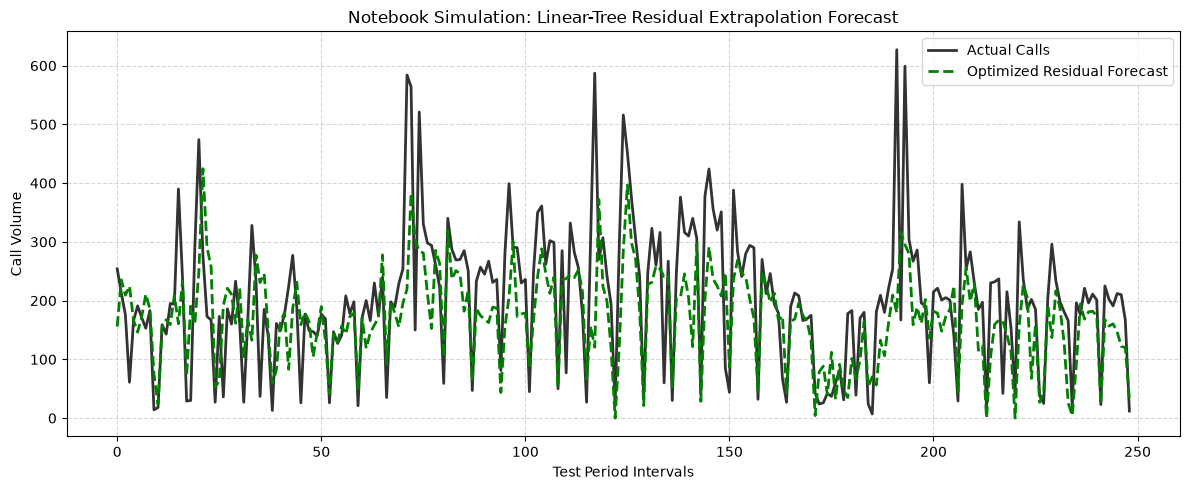

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# ==========================================
# 1. OPTIMIZER (WMAPE-Based Ensemble Blending)
# ==========================================
def optimus_simulation(pred_dict, y_true_array):
    """
    Notebook simulation of the optimus function using WMAPE objective.
    Prevents low-volume zero-division crashes and finds best blending weights.
    """
    model_names = list(pred_dict.keys())
    pred_matrix = np.array([pred_dict[m] for m in model_names]).T
    y_true = np.array(y_true_array, dtype=float)
    n_models = len(model_names)

    def wmape_loss(w):
        ensemble = pred_matrix.dot(w)
        total_actual = np.sum(np.abs(y_true))
        if total_actual == 0:
            return 0.0
        return (np.sum(np.abs(y_true - ensemble)) / total_actual) * 100.0

    x0 = np.ones(n_models) / n_models
    bounds = [(0.0, 1.0)] * n_models
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}

    res = minimize(wmape_loss, x0, method="SLSQP", bounds=bounds, constraints=cons)

    if not res.success or np.isnan(res.x).any():
        w = x0
    else:
        w = res.x

    w = np.where(w < 1e-3, 0.0, w)
    if w.sum() == 0:
        w = np.ones(n_models) / n_models
    else:
        w = w / w.sum()

    return dict(zip(model_names, np.round(w, 4)))

# ==========================================
# 2. DATA PREPROCESSING & SPIKE FEATURE ENGINEERING
# ==========================================
df_sim = df.copy()

# Parse time string helpers
def parse_time(time_val):
    if pd.isna(time_val): return 0.0
    val_str = str(time_val).strip()
    try:
        parts = val_str.split(':')
        if len(parts) == 3:
            return float(int(parts[0]) * 3600 + int(parts[1]) * 60 + int(float(parts[2])))
        elif len(parts) == 2:
            return float(int(parts[0]) * 60 + int(float(parts[1])))
    except Exception:
        pass
    return 0.0

# Clean percentages & times
for col in ['Answer Rate', 'Service Level (20 Seconds)']:
    if col in df_sim.columns:
        df_sim[col] = df_sim[col].astype(str).str.rstrip('%').apply(lambda x: pd.to_numeric(x, errors='coerce'))

for col in ['Answer Speed (AVG)', 'Talk Duration (AVG)', 'Waiting Time (AVG)']:
    if col in df_sim.columns:
        df_sim[col] = df_sim[col].apply(parse_time)

for col in ['Incoming Calls', 'Answered Calls', 'Abandoned Calls']:
    if col in df_sim.columns:
        df_sim[col] = pd.to_numeric(df_sim[col], errors='coerce')

df_sim = df_sim.fillna(0)
TARGET = 'Incoming Calls'

# Create Standard Time-Series Features
df_sim['lag_1'] = df_sim[TARGET].shift(1)
df_sim['lag_2'] = df_sim[TARGET].shift(2)
df_sim['lag_7'] = df_sim[TARGET].shift(7)
df_sim['rolling_mean_3'] = df_sim[TARGET].shift(1).rolling(3).mean()
df_sim['rolling_mean_7'] = df_sim[TARGET].shift(1).rolling(7).mean()

# Spike Momentum & Volatility Features
df_sim['rolling_max_3'] = df_sim[TARGET].shift(1).rolling(3).max()
df_sim['rolling_std_7'] = df_sim[TARGET].shift(1).rolling(7).std()

# Spike Multiplier Features
df_sim['spike_intensity'] = df_sim['lag_1'] / (df_sim['rolling_mean_7'] + 1e-5)
df_sim['is_spike_regime'] = (df_sim['spike_intensity'] > 1.5).astype(int)

# Drop initial NaN rows created by lags
df_clean = df_sim.dropna().reset_index(drop=True)

feature_cols = [
    'lag_1', 'lag_2', 'lag_7', 'rolling_mean_3', 'rolling_mean_7', 
    'rolling_max_3', 'rolling_std_7', 'spike_intensity', 'is_spike_regime',
    'Talk Duration (AVG)', 'Waiting Time (AVG)', 'Service Level (20 Seconds)'
]

X = df_clean[feature_cols].astype(float)
y = df_clean[TARGET].astype(float)

# ==========================================
# 3. TRAIN / TEST SPLIT
# ==========================================
split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ==========================================
# 4. LINEAR-TREE RESIDUAL HYBRID SIMULATION
# ==========================================
# Step A: Fit Base Linear Model for Scaling & Extrapolation
base_linear_model = LinearRegression()
base_linear_model.fit(X_train, y_train)

train_base_pred = base_linear_model.predict(X_train)
test_base_pred = base_linear_model.predict(X_test)

# Step B: Calculate Training Residuals (What Linear Model Missed)
train_residuals = y_train - train_base_pred

# Step C: Train Tree Models on Residuals
residual_models = {
    "Random Forest Res": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Res": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost Res": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
    "LightGBM Res": LGBMRegressor(n_estimators=50, max_depth=3, random_state=42, verbose=-1),
    "Ridge Res": Ridge(alpha=10.0)
}

test_preds = {}
for name, model in residual_models.items():
    model.fit(X_train, train_residuals)
    # Combine Linear Baseline + Tree Residual Correction
    combined_pred = test_base_pred + model.predict(X_test)
    test_preds[name] = np.maximum(0, combined_pred)  # Floor negative predictions at zero

# ==========================================
# 5. RUN OPTIMIZER & EVALUATE
# ==========================================
optimal_weights = optimus_simulation(test_preds, y_test.values)

# Build Weighted Ensemble array
ensemble_pred = np.zeros(len(y_test))
for name, weight in optimal_weights.items():
    ensemble_pred += weight * test_preds[name]

# Helper evaluation function
def calc_metrics(y_true, y_pred):
    wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100.0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    return round(wmape, 2), round(rmse, 2), round(mape, 2)

leaderboard = []
for name, preds in test_preds.items():
    wmape, rmse, mape = calc_metrics(y_test, preds)
    leaderboard.append({"Model": name, "WMAPE (%)": wmape, "RMSE": rmse, "Standard MAPE (%)": mape})

# Add Ensemble result
ens_wmape, ens_rmse, ens_mape = calc_metrics(y_test, ensemble_pred)
leaderboard.append({"Model": "⭐ Optimized Ensemble (Residual)", "WMAPE (%)": ens_wmape, "RMSE": ens_rmse, "Standard MAPE (%)": ens_mape})

results_df = pd.DataFrame(leaderboard).sort_values(by="WMAPE (%)")

print("=== OPTIMAL BLENDING WEIGHTS ===")
for k, v in optimal_weights.items():
    print(f"  • {k}: {v:.4f}")

print("\n=== MODEL LEADERBOARD SIMULATION ===")
print(results_df.to_string(index=False))

# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Calls', color='black', linewidth=2, alpha=0.8)
plt.plot(ensemble_pred, label='Optimized Residual Forecast', color='green', linestyle='--', linewidth=2)

plt.title('Notebook Simulation: Linear-Tree Residual Extrapolation Forecast')
plt.xlabel('Test Period Intervals')
plt.ylabel('Call Volume')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
